In [2]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.load_dataset("iris")
#list all the datasets available in seaborn
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
#load the iris and titanic dataset
iris = sns.load_dataset("iris")
titanic = sns.load_dataset("titanic")
print(iris.describe())
print(titanic.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7

In [5]:
iris.head()
#titanic.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

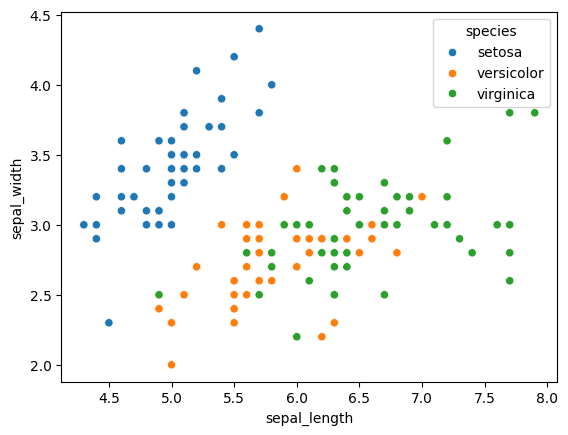

In [6]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")

In [7]:
iris[["sepal_length", "sepal_width"]].corr()

,sepal_length,sepal_width
sepal_length,1.00000,-0.11757
sepal_width,-0.11757,1.00000


In [8]:
#Calculate covarience and correlation matrix for the iris dataset
num_cols = iris.select_dtypes(include="number").columns
cov_matrix = iris[num_cols].cov()
corr_matrix = iris[num_cols].corr()
print("Covariance Matrix:")
print(cov_matrix)
print("\nCorrelation Matrix:")
print(corr_matrix)

Covariance Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


<Axes: >

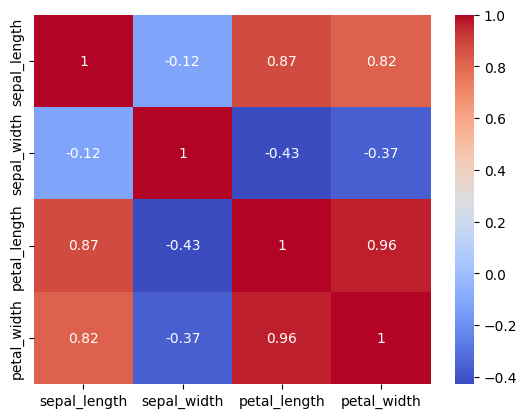

In [9]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

In [10]:
# Identify numerical and categorical columns in Iris dataset
iris_num_columns = iris.select_dtypes(include=['number']).columns
iris_cat_columns = iris.select_dtypes(exclude=['number']).columns
print(f"Numerical columns ({len(iris_num_columns)}): {list(iris_num_columns)}")
print(f"Categorical columns ({len(iris_cat_columns)}): {list(iris_cat_columns)}")


Numerical columns (4): ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Categorical columns (1): ['species']



Statistics for Iris - sepal_width:

Mean: 3.0573333333333337
Median: 3.0
Mode: 3.0
Standard Deviation: 0.4358662849366982
Variance: 0.189979418344519
Range: 2.4000000000000004



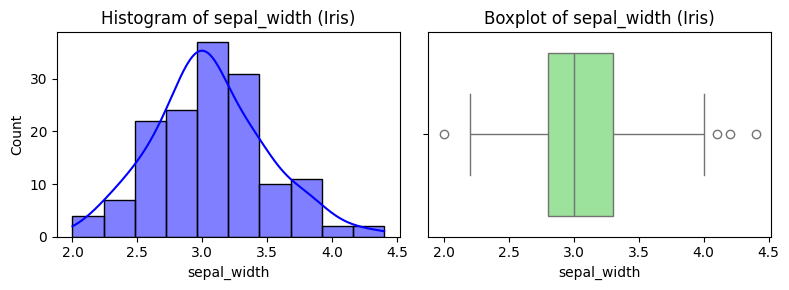

Outliers in sepal_width: 4
15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal_width, dtype: float64


In [11]:
# Numerical column analysis - Iris dataset
iris_num_col = input("\nEnter the name of a numerical column from Iris (e.g. sepal_length, sepal_width, petal_length, petal_width): ")
if iris_num_col in iris.columns:
    col_data = iris[iris_num_col]
    mean = col_data.mean()
    median = col_data.median()
    mode = col_data.mode().iloc[0] if not col_data.mode().empty else None
    std_dev = col_data.std()
    variance = col_data.var()
    value_range = col_data.max() - col_data.min()

    print(f"\nStatistics for Iris - {iris_num_col}:\n")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Variance: {variance}")
    print(f"Range: {value_range}\n")

    # Histogram and Boxplot
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(col_data, kde=True, bins=10, color='blue')
    plt.title(f"Histogram of {iris_num_col} (Iris)")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=col_data, color='lightgreen')
    plt.title(f"Boxplot of {iris_num_col} (Iris)")

    plt.tight_layout()
    plt.show()

    # Outlier detection using IQR
    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    print(f"Outliers in {iris_num_col}: {len(outliers)}")
    print(outliers)
else:
    print(f"Column '{iris_num_col}' not found in the Iris dataset.")


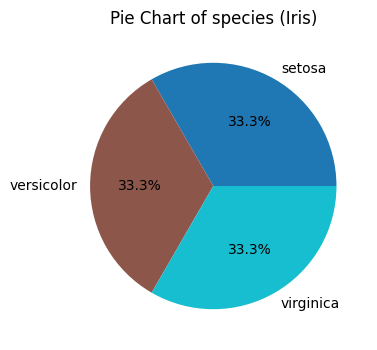


Frequency of categories in species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [12]:
# Categorical column analysis - Iris dataset
iris_cat_col = input("\nEnter the name of a categorical column from Iris (e.g. species): ")
if iris_cat_col in iris.columns:
    category_counts = iris[iris_cat_col].value_counts()
    chart_type = input("Choose chart type (bar/pie): ")
    if chart_type == 'bar':
        category_counts.plot(kind='bar', color='orange', figsize=(5, 3))
        plt.title(f"Bar Chart of {iris_cat_col} (Iris)")
        plt.xlabel(iris_cat_col)
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.tight_layout()
        plt.show()
    elif chart_type == 'pie':
        category_counts.plot(kind='pie', autopct="%.1f%%", figsize=(4, 4), colormap='tab10')
        plt.title(f"Pie Chart of {iris_cat_col} (Iris)")
        plt.ylabel("")
        plt.show()
    else:
        print("Invalid chart type. Please use 'bar' or 'pie'.")
    print(f"\nFrequency of categories in {iris_cat_col}:\n{category_counts}")
else:
    print(f"Column '{iris_cat_col}' not found in the Iris dataset.")


## Exp-1 Analysis on Titanic Dataset


In [13]:
# Identify numerical and categorical columns in Titanic dataset
titanic_num_columns = titanic.select_dtypes(include=['number']).columns
titanic_cat_columns = titanic.select_dtypes(exclude=['number']).columns
print(f"Numerical columns ({len(titanic_num_columns)}): {list(titanic_num_columns)}")
print(f"Categorical columns ({len(titanic_cat_columns)}): {list(titanic_cat_columns)}")


Numerical columns (6): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns (9): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']



Statistics for Titanic - fare:

Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05
Standard Deviation: 49.6934285971809
Variance: 2469.436845743116
Range: 512.3292



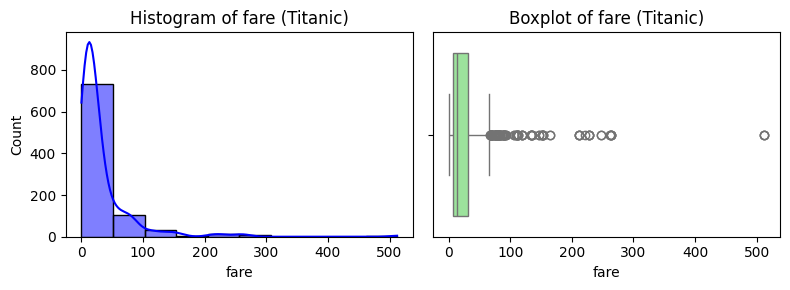

Outliers in fare: 116
1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: fare, Length: 116, dtype: float64


In [14]:
# Numerical column analysis - Titanic dataset
titanic_num_col = input("\nEnter the name of a numerical column from Titanic (e.g. age, fare, parch, sibsp): ")
if titanic_num_col in titanic.columns:
    col_data = titanic[titanic_num_col].dropna()
    mean = col_data.mean()
    median = col_data.median()
    mode = col_data.mode().iloc[0] if not col_data.mode().empty else None
    std_dev = col_data.std()
    variance = col_data.var()
    value_range = col_data.max() - col_data.min()

    print(f"\nStatistics for Titanic - {titanic_num_col}:\n")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Variance: {variance}")
    print(f"Range: {value_range}\n")

    # Histogram and Boxplot
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(col_data, kde=True, bins=10, color='blue')
    plt.title(f"Histogram of {titanic_num_col} (Titanic)")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=col_data, color='lightgreen')
    plt.title(f"Boxplot of {titanic_num_col} (Titanic)")

    plt.tight_layout()
    plt.show()

    # Outlier detection using IQR
    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    print(f"Outliers in {titanic_num_col}: {len(outliers)}")
    print(outliers)
else:
    print(f"Column '{titanic_num_col}' not found in the Titanic dataset.")


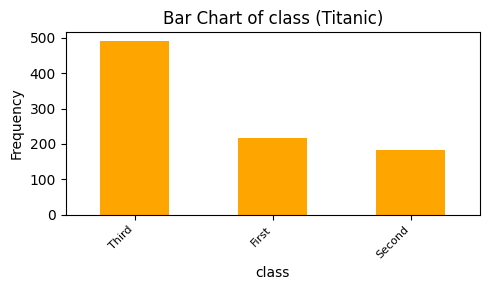


Frequency of categories in class:
class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [15]:
# Categorical column analysis - Titanic dataset
titanic_cat_col = input("\nEnter the name of a categorical column from Titanic (e.g. sex, embarked, class, who): ")
if titanic_cat_col in titanic.columns:
    category_counts = titanic[titanic_cat_col].value_counts()
    chart_type = input("Choose chart type (bar/pie): ")
    if chart_type == 'bar':
        category_counts.plot(kind='bar', color='orange', figsize=(5, 3))
        plt.title(f"Bar Chart of {titanic_cat_col} (Titanic)")
        plt.xlabel(titanic_cat_col)
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.tight_layout()
        plt.show()
    elif chart_type == 'pie':
        category_counts.plot(kind='pie', autopct="%.1f%%", figsize=(4, 4), colormap='tab10')
        plt.title(f"Pie Chart of {titanic_cat_col} (Titanic)")
        plt.ylabel("")
        plt.show()
    else:
        print("Invalid chart type. Please use 'bar' or 'pie'.")
    print(f"\nFrequency of categories in {titanic_cat_col}:\n{category_counts}")
else:
    print(f"Column '{titanic_cat_col}' not found in the Titanic dataset.")
